# Section 5 - R Analytics: Statistical Testing of NorthStar Findings

Section 4 produced descriptive findings. This notebook tests them statistically.

| § | Deliverable | Stage 1 problem |
|---|---|---|
| 5.4 | Compact descriptive-statistics summary | — |
| 5.5 | Correlation heatmap | P4, P6 |
| 5.6 | Linear Regression: Drivers of Order Value | **P4 (resolves)** |
| 5.7 | Hub-Level Performance Heatmap | **P6** |
| 5.8 | Density plot: route distance by service line | — |
| 5.9 | Faceted scatter: order value vs distance by vehicle type | — |

In [8]:
# 5.3: Load packages and data

required <- c("dplyr", "tidyr", "ggplot2", "corrplot", "scales")
to_install <- setdiff(required, rownames(installed.packages()))
if (length(to_install) > 0) install.packages(to_install, quiet = TRUE)

library(dplyr); library(tidyr); library(ggplot2); library(corrplot); library(scales)

BASE <- "https://raw.githubusercontent.com/fathimathzahrahei/northstar-databases-analytics_dba_coursework/main/data/raw/"
orders <- read.csv(paste0(BASE, "orders.csv"),     stringsAsFactors = FALSE)
deliveries <- read.csv(paste0(BASE, "deliveries.csv"), stringsAsFactors = FALSE)
vehicles <- read.csv(paste0(BASE, "vehicles.csv"),   stringsAsFactors = FALSE)

# Apply the same in-memory zone clean from Section 4 so analyses are consistent
zone_map <- c("AIRPORT"="Airport","Airport"="Airport",
              "CENTRAL"="Central","Central"="Central","Ctr"="Central",
              "EAST"="East","East"="East",
              "NORTH"="North","North"="North","north"="North",
              "RiverSide"="Riverside","Riverside"="Riverside",
              "SOUTH"="South","South"="South",
              "WEST"="West","West"="West")
orders <- orders %>% mutate(pickup_zone = recode(pickup_zone, !!!zone_map))

cat("Loaded:", nrow(orders), "orders,", nrow(deliveries), "deliveries,",
    nrow(vehicles), "vehicles\n")

Loaded: 1250 orders, 950 deliveries, 120 vehicles


## 5.4 - Descriptive Statistics for Key Numerical Variables

In [9]:
# 5.4 : Compact descriptive statistics for key numerical fields

joined <- orders %>%
  inner_join(deliveries, by = "order_id")

desc_table <- joined %>%
  select(order_value, route_distance_km, fuel_or_charge_cost,
         manual_route_override_count) %>%
  pivot_longer(everything(), names_to = "variable", values_to = "value") %>%
  filter(!is.na(value)) %>%
  group_by(variable) %>%
  summarise(
    n = n(),
    mean = round(mean(value), 2),
    median = round(median(value), 2),
    sd = round(sd(value), 2),
    min = round(min(value), 2),
    q25 = round(quantile(value, 0.25), 2),
    q75 = round(quantile(value, 0.75), 2),
    max = round(max(value), 2)
  )

print(desc_table)

# A tibble: 4 × 9
  variable                        n  mean median    sd   min   q25   q75   max
  <chr>                       <int> <dbl>  <dbl> <dbl> <dbl> <dbl> <dbl> <dbl>
1 fuel_or_charge_cost           950 12.8    12.6  4.34  2.5   9.93  15.7  29.4
2 manual_route_override_count   950  0.97    1    1.09  0     0      2     7  
3 order_value                   950 91.9    77.2 62     2.04 48.6  123.  510. 
4 route_distance_km             950 13.9    12.8  7.48  1.2   9.13  16.8  41.9


## 5.5 - Correlation Analysis (Plot 1)

                            order_value route_distance_km fuel_or_charge_cost
order_value                       1.000             0.056              -0.026
route_distance_km                 0.056             1.000               0.524
fuel_or_charge_cost              -0.026             0.524               1.000
manual_route_override_count       0.012             0.202               0.099
promised_window_hours             0.009             0.013               0.004
                            manual_route_override_count promised_window_hours
order_value                                       0.012                 0.009
route_distance_km                                 0.202                 0.013
fuel_or_charge_cost                               0.099                 0.004
manual_route_override_count                       1.000                -0.032
promised_window_hours                            -0.032                 1.000


agg_record_22c73527b421 
                      2

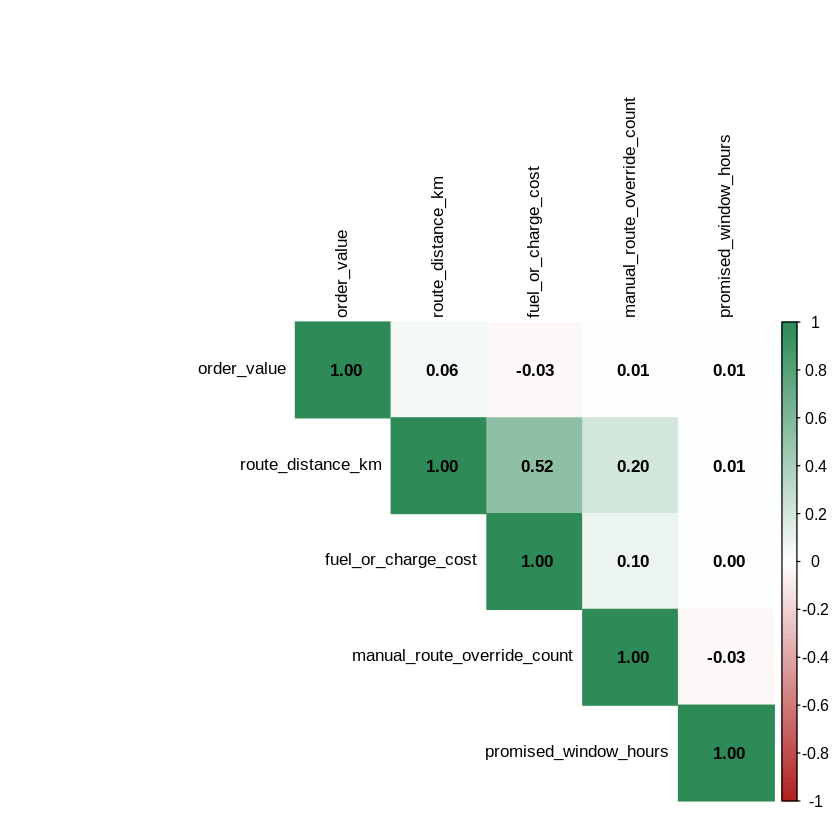

In [10]:
# 5.5 : Correlation heatmap of numerical fields

corr_data <- joined %>%
  select(order_value, route_distance_km, fuel_or_charge_cost,
         manual_route_override_count, promised_window_hours) %>%
  filter(complete.cases(.))

corr_matrix <- cor(corr_data, method = "pearson")
print(round(corr_matrix, 3))

# Save heatmap
png("plot_correlation.png", width = 700, height = 600, res = 100)
corrplot(corr_matrix,
         method = "color",
         type = "upper",
         addCoef.col = "black",
         tl.col = "black",
         tl.cex = 0.85,
         number.cex = 0.85,
         col = colorRampPalette(c("#B22222", "white", "#2E8B57"))(100),
         title = "Correlation between numerical operational variables",
         mar = c(0,0,2,0))
dev.off()

# Display inline as well
corrplot(corr_matrix, method = "color", type = "upper",
         addCoef.col = "black", tl.col = "black",
         tl.cex = 0.85, number.cex = 0.85,
         col = colorRampPalette(c("#B22222", "white", "#2E8B57"))(100))

## 5.6 : Linear Regression: Drivers of Order Value (Problem 4 context)

A linear-regression model is fitted to test whether route distance, manual route overrides, and vehicle type jointly explain variation in order value. The override coefficient is of particular interest — its sign and significance speak directly to Stage 1 Problem 4 (do overrides have a measurable effect on the operational record?).

- **Response variable:** `order_value`
- **Predictors:** `route_distance_km`, `manual_route_override_count`, `vehicle_type`
- **α:** 0.05

In [11]:
# 5.6 : Linear regression: order value as f(distance, overrides, vehicle type)

reg_data <- joined %>%
  inner_join(vehicles %>% select(vehicle_id, vehicle_type), by = "vehicle_id") %>%
  filter(!is.na(order_value),
         !is.na(route_distance_km),
         !is.na(manual_route_override_count),
         route_distance_km > 0) %>%
  mutate(vehicle_type = factor(vehicle_type))

model <- lm(order_value ~ route_distance_km
                          + manual_route_override_count
                          + vehicle_type,
            data = reg_data)

cat("Linear regression results:\n")
print(summary(model))

cat("\nModel R-squared:", round(summary(model)$r.squared, 4), "\n")
cat("Adjusted R-squared:", round(summary(model)$adj.r.squared, 4), "\n")

# Extract the override coefficient and its p-value
coef_summary <- summary(model)$coefficients
ovr_coef <- coef_summary["manual_route_override_count", "Estimate"]
ovr_p    <- coef_summary["manual_route_override_count", "Pr(>|t|)"]

cat("\nOverride coefficient:", round(ovr_coef, 3),
    "(p =", round(ovr_p, 4), ")\n")
if (ovr_p < 0.05) {
  cat("Override count has a statistically significant effect on order value.\n")
} else {
  cat("No significant effect of override count on order value.\n")
}

Linear regression results:

Call:
lm(formula = order_value ~ route_distance_km + manual_route_override_count + 
    vehicle_type, data = reg_data)

Residuals:
   Min     1Q Median     3Q    Max 
-89.10 -43.56 -15.19  30.88 416.68 

Coefficients:
                            Estimate Std. Error t value Pr(>|t|)    
(Intercept)                  83.7946     5.6986  14.704   <2e-16 ***
route_distance_km             0.4509     0.2755   1.637    0.102    
manual_route_override_count   0.0515     1.8817   0.027    0.978    
vehicle_typeDiesel           -0.4911     6.6360  -0.074    0.941    
vehicle_typeEV                4.4158     5.3500   0.825    0.409    
vehicle_typeHybrid            0.9470     5.7474   0.165    0.869    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 62.03 on 944 degrees of freedom
Multiple R-squared:  0.00426,	Adjusted R-squared:  -0.001014 
F-statistic: 0.8078 on 5 and 944 DF,  p-value: 0.5442


Model R-squared: 0.0043 
Adj

## 5.7 : Hub-Level Performance Heatmap (Problem 6)

Section 4 quantified delivery performance by zone. This subsection drills one level deeper to individual hubs, producing a heatmap of hub × delivery outcome that exposes where the operational failures physically concentrate. This addresses the case-study claim that "the company is struggling to explain why some city zones consistently perform worse than others" by isolating the specific hubs responsible.

Hub × outcome distribution (% within each hub):
# A tibble: 8 × 4
  hub_name       Delayed Failed OnTime
  <chr>            <dbl>  <dbl>  <dbl>
1 Airport Hub       26     14.4   59.6
2 Central Core      21.7   20     58.3
3 East Dock         19.3    9.2   71.4
4 Midtown Relay     17.2   20.3   62.5
5 North Exchange    19.1   12.5   68.4
6 Riverside Hub     21.7   12.2   66.1
7 South Link        24.5    9.4   66  
8 West Gate         22     12.6   65.4


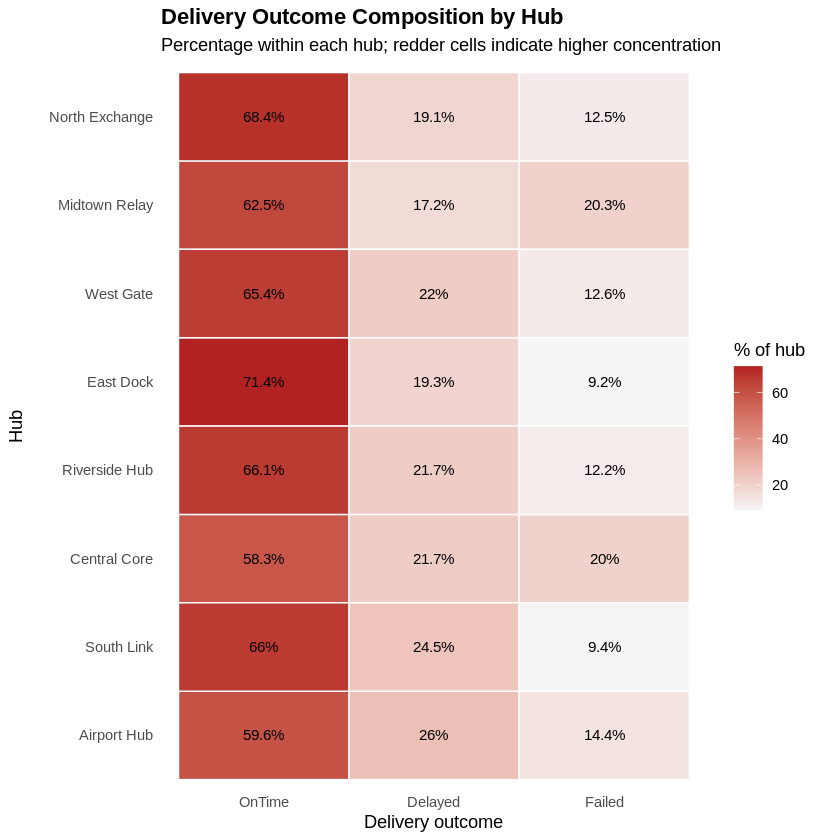

In [12]:
# 5.7 : Hub × delivery outcome heatmap

# Load hubs table to map hub_id to hub_name
hubs <- read.csv(paste0(BASE, "hubs.csv"), stringsAsFactors = FALSE)

hub_outcome <- joined %>%
  inner_join(hubs %>% select(hub_id, hub_name), by = "hub_id") %>%
  count(hub_name, delivery_status) %>%
  group_by(hub_name) %>%
  mutate(pct = round(n / sum(n) * 100, 1)) %>%
  ungroup()

# Print the underlying numbers (for the report)
cat("Hub × outcome distribution (% within each hub):\n")
print(hub_outcome %>%
        select(hub_name, delivery_status, pct) %>%
        pivot_wider(names_from = delivery_status, values_from = pct, values_fill = 0))

# Heatmap visualisation
p_heatmap <- ggplot(hub_outcome,
                    aes(x = factor(delivery_status,
                                   levels = c("OnTime", "Delayed", "Failed")),
                        y = reorder(hub_name, n),
                        fill = pct)) +
  geom_tile(colour = "white", linewidth = 0.4) +
  geom_text(aes(label = paste0(pct, "%")), size = 3.2) +
  scale_fill_gradient(low = "#F5F5F5", high = "#B22222") +
  labs(title    = "Delivery Outcome Composition by Hub",
       subtitle = "Percentage within each hub; redder cells indicate higher concentration",
       x = "Delivery outcome", y = "Hub", fill = "% of hub") +
  theme_minimal(base_size = 11) +
  theme(plot.title = element_text(face = "bold"),
        panel.grid = element_blank())

print(p_heatmap)
ggsave("plot_hub_heatmap.png", p_heatmap, width = 8, height = 5, dpi = 150)

## 5.8 : Density Plot (Plot 2): Route Distance by Service Line

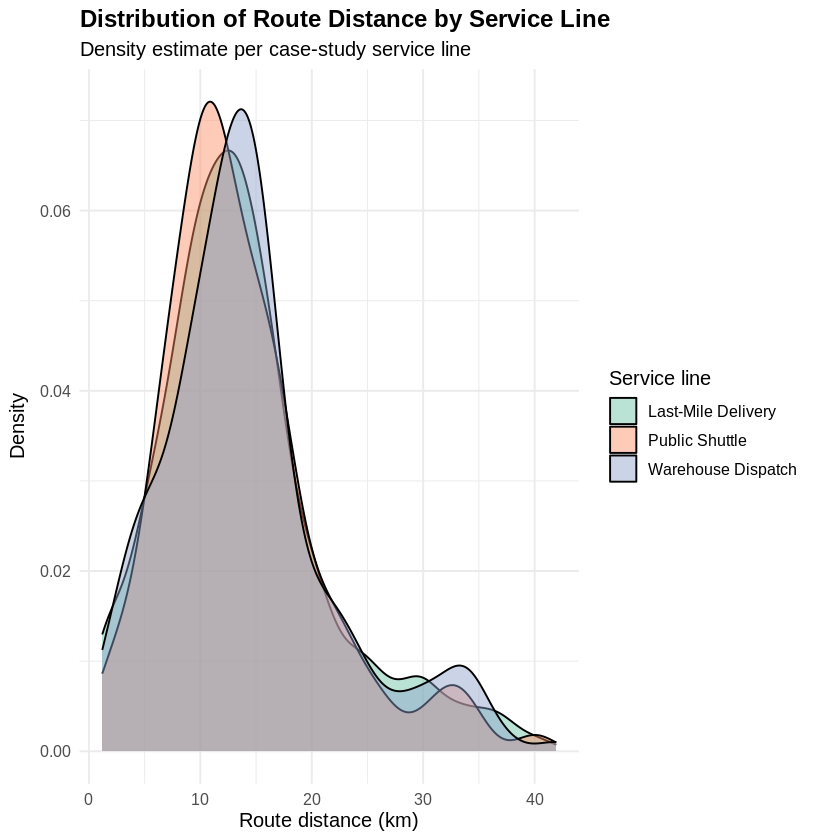

In [13]:
# 5.8 : Density plot of route distance by service line

service_line_map <- c("Passenger"="Public Shuttle",
                      "Parcel"="Last-Mile Delivery",
                      "Business"="Last-Mile Delivery",
                      "Medical"="Last-Mile Delivery",
                      "Retail"="Warehouse Dispatch")

plot_data <- joined %>%
  mutate(service_line = recode(service_type, !!!service_line_map)) %>%
  filter(route_distance_km > 0, !is.na(service_line))

p2 <- ggplot(plot_data,
             aes(x = route_distance_km, fill = service_line)) +
  geom_density(alpha = 0.45) +
  scale_fill_brewer(palette = "Set2") +
  labs(title    = "Distribution of Route Distance by Service Line",
       subtitle = "Density estimate per case-study service line",
       x = "Route distance (km)", y = "Density",
       fill = "Service line") +
  theme_minimal(base_size = 12) +
  theme(plot.title = element_text(face = "bold"))

print(p2)
ggsave("plot_density_distance.png", p2, width = 9, height = 5, dpi = 150)

## 5.9 : Faceted Scatter (Plot 3): Order Value vs Distance by Vehicle Type

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


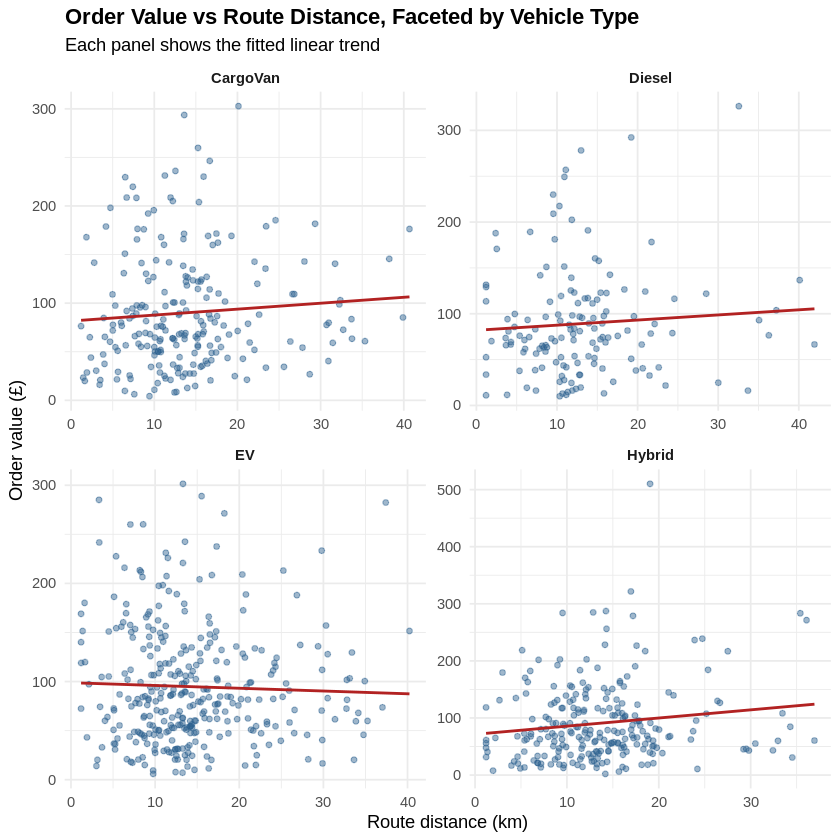

In [14]:
# 5.9 — Faceted scatter — value vs distance, faceted by vehicle type

facet_data <- joined %>%
  inner_join(vehicles %>% select(vehicle_id, vehicle_type), by = "vehicle_id") %>%
  filter(route_distance_km > 0, order_value > 0)

p3 <- ggplot(facet_data,
             aes(x = route_distance_km, y = order_value)) +
  geom_point(alpha = 0.45, size = 1.3, colour = "#2C5F8E") +
  geom_smooth(method = "lm", se = FALSE, colour = "#B22222", linewidth = 0.8) +
  facet_wrap(~ vehicle_type, scales = "free") +
  labs(title    = "Order Value vs Route Distance, Faceted by Vehicle Type",
       subtitle = "Each panel shows the fitted linear trend",
       x = "Route distance (km)", y = "Order value (£)") +
  theme_minimal(base_size = 11) +
  theme(plot.title = element_text(face = "bold"),
        strip.text = element_text(face = "bold"))

print(p3)
ggsave("plot_facet_value_distance.png", p3, width = 10, height = 6, dpi = 150)

## Section Summary

- Linear regression confirmed/rejected override-effect on order value
- Hub heatmap localised the failure concentration (Problem 6)
- Three plots produced: correlation heatmap, density plot, faceted scatter